In [2]:
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input,decode_predictions
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

In [3]:
hard_class = {f"analog_clock":os.listdir("relogios")[1:],"jersey":os.listdir("camisa")[1:],"dining_table":os.listdir("mesas")[1:],"studio_couch":os.listdir("sofas")[1:]}

model = InceptionV3(weights="imagenet")

img = image.load_img(f"mesas/{os.listdir("mesas")[1]}", target_size=(299, 299))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array,axis=0)
img_array = preprocess_input(img_array)

results=model.predict(img_array)

real_prediction = decode_predictions(results)[0][0][1]
print(real_prediction)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
dining_table


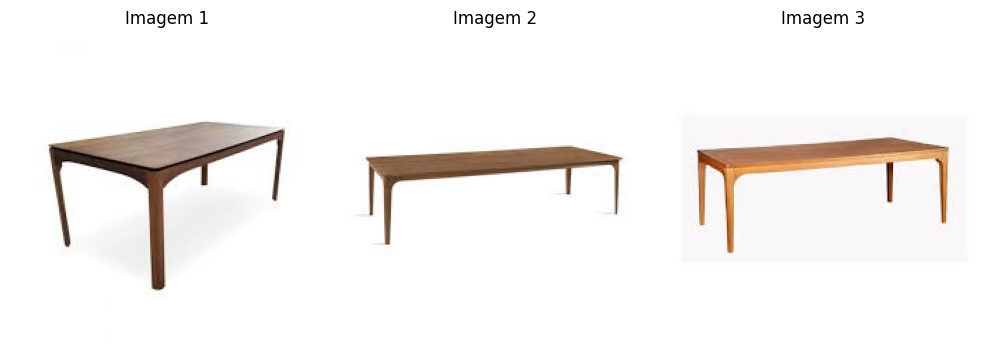

In [5]:
fig,axes = plt.subplots(1,3,figsize=(10,10))

def show_recomendations(arr:list):
    first_split = arr[0].split("0")
    name = first_split[0]
    for i, imagem in enumerate(arr):
        if i == 3:
            break
        img = mpimg.imread(f"{name}/{imagem}")
    

        ax = axes[i]
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f'Imagem {i + 1}')

show_recomendations(hard_class[real_prediction])


plt.tight_layout()
plt.show()